In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from scipy.stats import t

In [2]:
df_ctrp=pd.read_csv("../../Desktop/EDGE/Drug_sensitivity_AUC_(CTD^2).csv")
df_ctrp.index=df_ctrp.iloc[:, 0]
df_ctrp.drop('Unnamed: 0', axis=1, inplace=True)
df_ctrp.columns=[i.split(' (')[0] for i in df_ctrp.columns]

In [3]:
df_ctrp.head()

,CIL56,FQI-1,BRD-K92856060,B02,BRD6340,BRD-K45681478,ML050,ML162,CIL41,ML006,...,BCL-LZH-4,skepinone-L,BRD-K34222889,PF-4800567,avicin D,BRD9876:MK-1775,BRD-K30748066,linsitinib,AT-406,ML031
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ACH-000002,NaN,NaN,13.349,12.987,14.904,13.517,14.709,10.4670,NaN,14.634,...,15.139,14.489,10.7010,15.740,12.6930,NaN,NaN,11.682,14.231,13.676
ACH-000004,11.733,10.825,13.911,13.445,14.193,15.000,15.689,7.0524,14.780,14.513,...,NaN,NaN,9.9767,NaN,NaN,NaN,NaN,16.917,NaN,15.715
ACH-000005,NaN,NaN,13.646,12.313,13.739,13.328,14.662,6.7487,NaN,14.532,...,14.460,13.254,10.5430,14.575,9.9691,NaN,NaN,16.538,14.004,12.914
ACH-000006,NaN,NaN,NaN,NaN,14.016,11.103,NaN,9.8786,NaN,NaN,...,NaN,NaN,9.2081,NaN,NaN,NaN,NaN,12.054,13.839,NaN
ACH-000007,14.562,11.469,14.418,12.920,14.742,12.056,15.638,8.5650,15.313,14.302,...,NaN,NaN,10.5100,NaN,NaN,NaN,NaN,11.212,NaN,14.694


In [4]:
h=pd.read_csv("../../Desktop/EDGE/h.tsv", sep='\t', index_col=0)

In [5]:
h.head()

,ACH-000276,ACH-000856,ACH-000223,ACH-000643,ACH-000857,ACH-000196,ACH-000258,ACH-000691,ACH-000374,ACH-000148,...,ACH-000624,ACH-000699,ACH-001390,ACH-001388,ACH-000536,ACH-001819,ACH-000212,ACH-000849,ACH-000288,ACH-001391
Factor,,,,,,,,,,,,,,,,,,,,,
F0,11.610072,0.000000,4.002012,4.467511,2.842100,15.709045,0.000000,16.923620,12.316971,0.000000,...,2.238540,7.116501,1.118149,0.000000,0.000000,0.000000,0.000000,3.299761,2.025203,0.000000
F1,4.032979,0.964079,0.000000,0.242386,0.902854,0.000000,0.000000,0.000000,3.473802,16.217562,...,0.000000,12.706818,2.251990,0.000000,2.115427,0.000000,3.495978,0.842810,14.404104,12.658404
F2,3.429176,5.462631,0.831522,0.000000,0.000000,8.643709,0.000000,11.089436,0.868002,0.000000,...,0.000000,0.000000,3.650204,3.390343,5.577368,16.649480,3.448298,0.356707,0.000000,0.000000
F3,7.874484,0.000000,13.926229,13.741332,15.951980,0.000000,1.070025,0.000000,19.460527,0.000000,...,13.149101,4.641745,28.448518,22.046274,0.000000,2.269251,5.219216,1.943138,0.000000,11.011505
F4,4.250989,2.670393,1.174707,1.253105,2.555877,0.000000,33.188613,0.034767,2.802892,0.000000,...,5.143363,0.000000,1.955608,0.000000,0.000000,0.000000,0.000000,1.332209,0.000000,0.000000


In [6]:
cell_lines_order = ['ACH-000691', 'ACH-000196', 'ACH-000111', 'ACH-000276', 'ACH-000721', 'ACH-000148', 'ACH-001389', 'ACH-000621', 'ACH-000288', 'ACH-000573', 'ACH-000699', 'ACH-001391',
                   'ACH-001392', 'ACH-001819', 'ACH-000910', 'ACH-000374', 'ACH-001388', 'ACH-001390', 'ACH-001394',
                   'ACH-000643', 'ACH-000624', 'ACH-000857', 'ACH-000223', 'ACH-000668', 'ACH-000258',
                   'ACH-000856', 'ACH-000212', 'ACH-000768', 'ACH-000849', 'ACH-000536']

In [7]:
#This is to match TNBC cell lines from drug response dataframe and state score dataframe
df_ctrp_tnbc = df_ctrp.loc[df_ctrp.index.isin(cell_lines_order),]
nan_counts = df_ctrp_tnbc.isna().sum()
columns_to_keep = nan_counts[nan_counts <= 10].index #to filter out drugs with a lot of missing values in TNBC cell lines
df_ctrp_tnbc_cleaned = df_ctrp_tnbc[columns_to_keep]

In [8]:
#To normalize state scores in the h.tsv file
h2=pd.DataFrame(sp.stats.zscore(h, axis=0)) #z-score for each column (column-wise), so that the computated z-score matches the h.html
h2.index=h.index
h2.columns=h.columns

In [9]:
#For F0
df_f0 =h2.loc[h2.index=="F0", h2.columns.isin(df_ctrp_tnbc.index)].transpose()

#merge drug response and F0 scores by cell line index
df_merged_f0=pd.merge(df_ctrp_tnbc_cleaned, df_f0, left_index=True, right_index=True)

last_col = df_merged_f0.iloc[:, -1]

# Loop through each column except the last one 
# compute Pearson correlation between drug response and F0 state
correlations = {}
for col in df_merged_f0.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f0[[col, "F0"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F0"])
    
# Convert the dictionary to a DataFrame
correlation_df_f0 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f0[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f0['Info'].tolist(), index=correlation_df_f0.index)
correlation_df_f0 = correlation_df_f0.drop(columns=['Info'])

In [10]:
correlation_df_f0["CCLE_model_state"] = "F0"
correlation_df_f0["State_description"] = "partial-EMT & NOTCH signaling"
correlation_df_f0["Salient_representative_genes"] = [["ELF3", "GRHL2", "CLDN4", "DSP", "CGN", "DSC2", "ALDH1A3","JAG2", "NOTCH1", "HES4", "HEY2", "NOTCH2", "NOTCH3"]] * len(correlation_df_f0)

In [11]:
correlation_df_f0.loc[(correlation_df_f0['P-value'] < 0.05) & (correlation_df_f0['Correlation'] < 0),].sort_values(by=['Correlation', 'P-value'], ascending=[True, True])

,Drug,Correlation,P-value,CCLE_model_state,State_description,Salient_representative_genes
321,YL54,-0.749252,0.001303,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."
13,CIL70,-0.676224,0.045516,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."
12,Bax channel blocker,-0.626515,0.009407,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."
245,TGX-221,-0.534903,0.026939,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."
83,necrostatin-1,-0.524626,0.036944,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."
106,BRD-K13999467,-0.519783,0.032469,F0,partial-EMT & NOTCH signaling,"[ELF3, GRHL2, CLDN4, DSP, CGN, DSC2, ALDH1A3, ..."


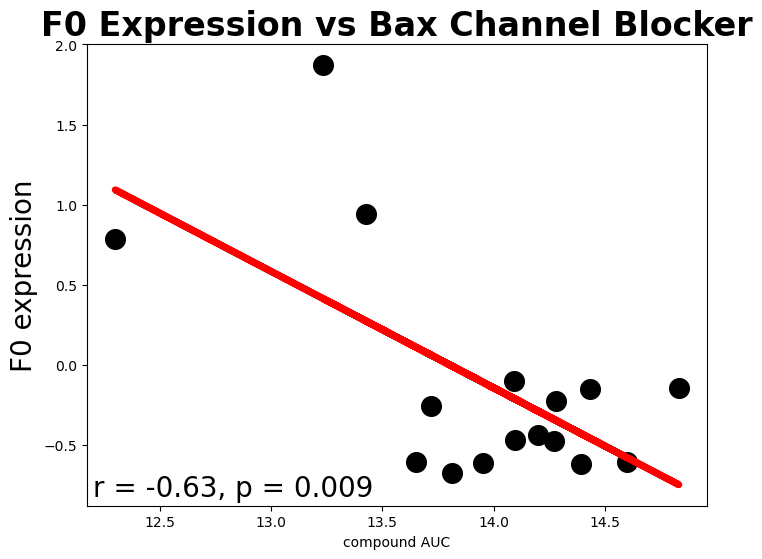

In [37]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f0[["Bax channel blocker", "F0"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F0 expression', fontsize=20)
# Add correlation + p-value annotation
plt.text(0.01, 0.02, f"r = {r_value:.2f}, p = {p_value:.3f}", transform=plt.gca().transAxes, fontsize = 20)
plt.title("F0 Expression vs Bax Channel Blocker", fontsize=24,fontweight='bold')
plt.grid(False)
#plt.savefig(f"plots/YL54_vs_F0_zscore_06302025.png",dpi=300)
plt.show()

In [13]:
#For F1
df_f1 =h2.loc[h2.index=="F1", h2.columns.isin(df_ctrp_tnbc.index)].transpose()
df_merged_f1=pd.merge(df_ctrp_tnbc_cleaned, df_f1, left_index=True, right_index=True)

last_col = df_merged_f1.iloc[:, -1]

# Loop through each column except the last one
correlations = {}
for col in df_merged_f1.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f1[[col, "F1"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F1"])
    
# Convert the dictionary to a DataFrame
correlation_df_f1 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f1[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f1['Info'].tolist(), index=correlation_df_f1.index)
correlation_df_f1 = correlation_df_f1.drop(columns=['Info'])

In [14]:
correlation_df_f1["CCLE_model_state"] = "F1"
correlation_df_f1["State_description"] = "MYC-high & EMT & hypoxia | glycolysis"
correlation_df_f1["Salient_representative_genes"] = [["MYC", "TGFBI", "SNAI2", "MMP2", "FN1", "CDH2", "VIM", "GSTP1", "LDHB"]] * len(correlation_df_f1)

In [15]:
correlation_df_f1.loc[(correlation_df_f1['P-value'] < 0.05) & (correlation_df_f1['Correlation'] < 0),].sort_values(by=['Correlation', 'P-value'], ascending=[True, True])

,Drug,Correlation,P-value,CCLE_model_state,State_description,Salient_representative_genes
480,CBB-1007,-0.870137,0.002283,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
468,palmostatin B,-0.755565,0.007158,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
484,SZ4TA2,-0.711397,0.031624,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
185,BRD-K37390332,-0.679211,0.002712,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
116,SID 26681509,-0.678749,0.010747,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
204,GSK-3-inhibitor-IX,-0.675633,0.002913,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
470,BRD-K99006945,-0.672748,0.047069,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
489,PF-4800567,-0.671733,0.047529,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
425,AT7867,-0.665134,0.004930,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."
413,fluvastatin,-0.578894,0.023750,F1,MYC-high & EMT & hypoxia | glycolysis,"[MYC, TGFBI, SNAI2, MMP2, FN1, CDH2, VIM, GSTP..."


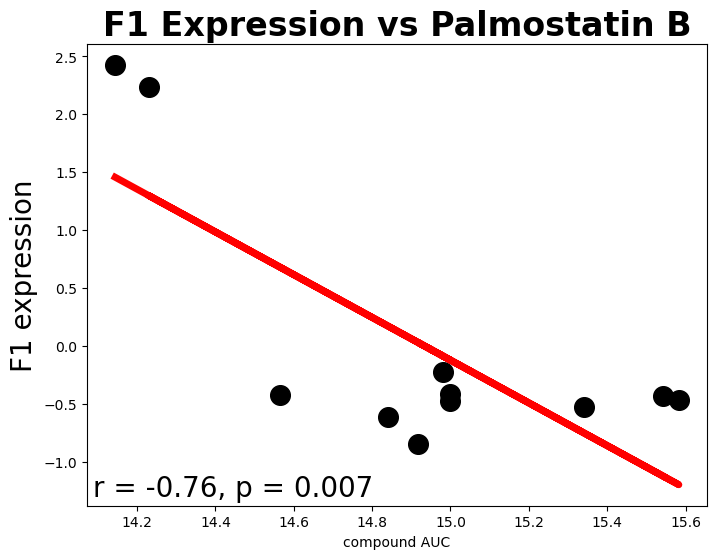

In [35]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f1[["palmostatin B", "F1"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F1 expression', fontsize=20)
plt.text(0.01, 0.02, f"r = {r_value:.2f}, p = {p_value:.3f}", transform=plt.gca().transAxes, fontsize = 20)
plt.title("F1 Expression vs Palmostatin B", fontsize=24,fontweight='bold')
plt.grid(False)
#plt.savefig('/Volumes/SSD_Yue/TNBC_paper_Fig2_10252024/CBB-1007_AUC_vs_F1_zscore_12112024.svg',dpi=300)
plt.show()

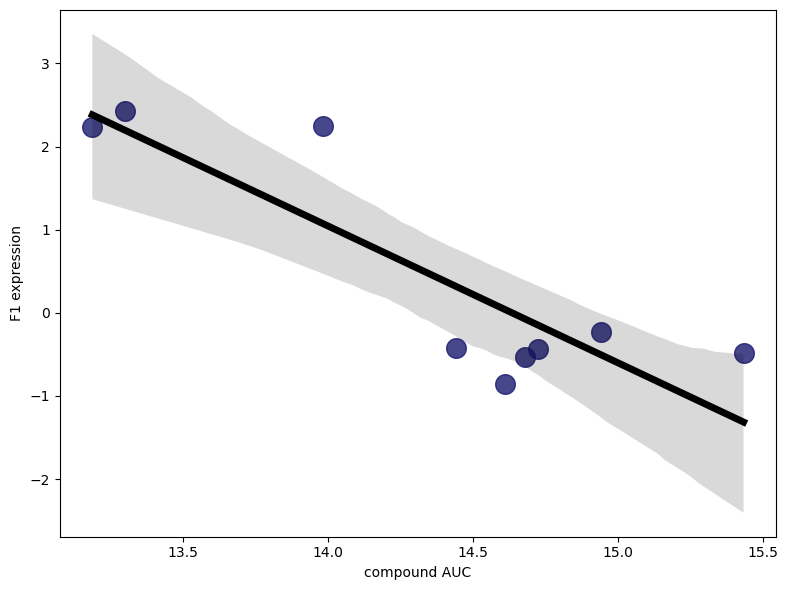

In [17]:
# ci intervals
df_tmpt = df_merged_f1[["CBB-1007", "F1"]].replace([np.inf, -np.inf], np.nan).dropna()

# Create plot
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_tmpt,
    x="CBB-1007",
    y="F1",
    ci=95,  # 95% confidence interval
    scatter_kws={"color": "midnightblue", "s": 200},
    line_kws={"color": "black", "linewidth": 5}
)

# Labeling
plt.xlabel('compound AUC')
plt.ylabel('F1 expression')
plt.grid(False)
plt.tight_layout()
plt.show()

In [18]:
#For F2
df_f2 =h2.loc[h2.index=="F2", h2.columns.isin(df_ctrp_tnbc.index)].transpose()
df_merged_f2=pd.merge(df_ctrp_tnbc_cleaned, df_f2, left_index=True, right_index=True)

last_col = df_merged_f2.iloc[:, -1]

# Loop through each column except the last one
correlations = {}
for col in df_merged_f2.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f2[[col, "F2"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F2"])
    
# Convert the dictionary to a DataFrame
correlation_df_f2 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f2[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f2['Info'].tolist(), index=correlation_df_f2.index)
correlation_df_f2 = correlation_df_f2.drop(columns=['Info'])

In [19]:
correlation_df_f2["CCLE_model_state"] = "F2"
correlation_df_f2["State_description"] = "luminal-like & PI3K-Akt signaling"
correlation_df_f2["Salient_representative_genes"] = [["CD24", "KRT19", "NRG3", "ERBB3", "TSPAN1", "FGFR4"]] * len(correlation_df_f2)

In [20]:
pd.set_option('display.max_row', None)
correlation_df_f2.loc[(correlation_df_f2['P-value'] < 0.05) & (correlation_df_f2['Correlation'] < 0),].sort_values(by=['Correlation', 'P-value'], ascending=[True, True])

,Drug,Correlation,P-value,CCLE_model_state,State_description,Salient_representative_genes
289,OSI-930,-0.799180,0.000605,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
323,BRD-K55473186,-0.786053,0.004123,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
175,BRD-K02251932,-0.757661,0.000674,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
66,BRD-K90370028,-0.741528,0.035234,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
486,BCL-LZH-4,-0.727911,0.026193,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
28,trifluoperazine,-0.716227,0.003958,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
304,sonidegib,-0.707700,0.001018,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
478,MI-2,-0.689729,0.039795,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
159,BIBR-1532,-0.674922,0.002120,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"
174,BRD-K64610608,-0.671129,0.003183,F2,luminal-like & PI3K-Akt signaling,"[CD24, KRT19, NRG3, ERBB3, TSPAN1, FGFR4]"


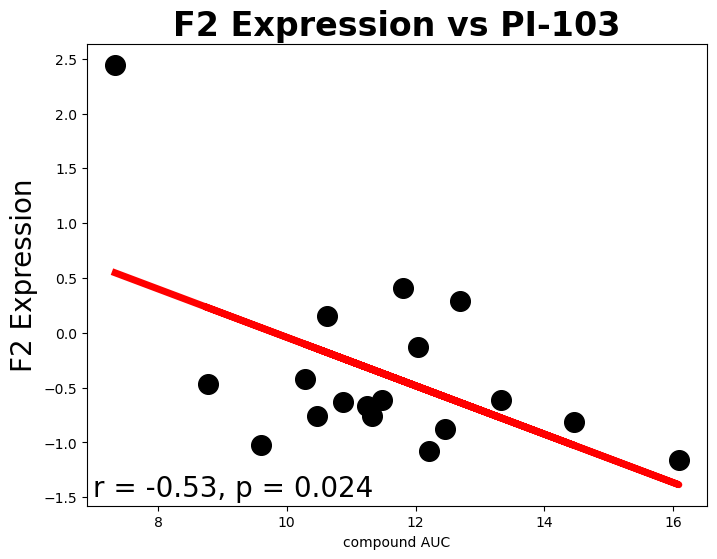

In [39]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f2[["PI-103", "F2"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F2 Expression', fontsize=20)
plt.text(0.01, 0.02, f"r = {r_value:.2f}, p = {p_value:.3f}", transform=plt.gca().transAxes, fontsize= 20)
plt.title("F2 Expression vs PI-103", fontsize=24,fontweight='bold')
plt.grid(False)
#plt.savefig('/Volumes/SSD_Yue/TNBC_paper_Fig2_10252024/PI-103_CCLE_F2_score_10272024.svg',dpi=300)
plt.show()

In [22]:
correlation_df_f2.loc[(correlation_df_f2['P-value'] < 0.05) & (correlation_df_f2['Correlation'] < 0),].Drug.tolist()

['BRD-K92856060',
 'trifluoperazine',
 'ciclopirox',
 'BRD-K90370028',
 'BRD-K14844214',
 'BRD-K63431240',
 '16-beta-bromoandrosterone',
 'PRL-3 inhibitor I',
 'PI-103',
 'oligomycin A',
 'CCT036477',
 'BIBR-1532',
 'BRD-K04800985',
 'BRD-K64610608',
 'BRD-K02251932',
 'SB-431542',
 'panobinostat',
 'vorinostat',
 'SU11274',
 'OSI-930',
 'ISOX',
 'sonidegib',
 'GDC-0941',
 'BRD-K55473186',
 'spautin-1',
 'BRD-K97651142',
 'BAM7',
 'PIK-93',
 'MI-2',
 'BCL-LZH-4',
 'ML031']

## F0-F2 corr


In [ ]:
# Function to compute correlation with a specific state
def compute_state_correlations(state_name):
    state_series = h_2.loc[state_name].dropna()
    common_cells = df_ctrp_tnbc_cleaned.index.intersection(state_series.index)
    result = []

    for drug in df_ctrp_tnbc_cleaned.columns:
        auc_values = df_ctrp_tnbc_cleaned.loc[common_cells, drug]
        state_values = state_series.loc[common_cells]
        if auc_values.isna().sum() <= 5:
            auc_values = auc_values.astype(float)
            state_values = state_values.astype(float)
            valid = (~auc_values.isna()) & (~state_values.isna())
            if valid.sum() > 2:
                r, p = pearsonr(auc_values[valid], state_values[valid])
                result.append((drug, r, p))
    return pd.DataFrame(result, columns=["Drug", "Correlation", "Pvalue"])

In [ ]:
merged.head()

In [ ]:
significant = merged[(merged['F0_Pvalue'] < 0.05) | (merged['F1_Pvalue'] < 0.05) | (merged['F2_Pvalue'] < 0.05)]

In [ ]:
#For F3
df_f3 =h2.loc[h2.index=="F3", h2.columns.isin(df_ctrp_tnbc.index)].transpose()
df_merged_f3=pd.merge(df_ctrp_tnbc_cleaned, df_f3, left_index=True, right_index=True)

last_col = df_merged_f3.iloc[:, -1]

# Loop through each column except the last one
correlations = {}
for col in df_merged_f3.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f3[[col, "F3"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F3"])
    
# Convert the dictionary to a DataFrame
correlation_df_f3 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f3[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f3['Info'].tolist(), index=correlation_df_f3.index)
correlation_df_f3 = correlation_df_f3.drop(columns=['Info'])

In [ ]:
correlation_df_f3["CCLE_model_state"] = "F3"
correlation_df_f3["State_description"] = "EGFR signaling & NF-kB signaling"
correlation_df_f3["Salient_representative_genes"] = [["AREG", "TGFA", "BTC", "EPGN", "EFEMP1", "TNS4", "GPR87", "IL18", "TNIP2", "TNF", "TNFAIP2"]] * len(correlation_df_f3)

In [ ]:
correlation_df_f3.loc[(correlation_df_f3['P-value'] < 0.1) & (correlation_df_f3['Correlation'] < 0),]

In [ ]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f3[["erlotinib", "F3"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F3 expression')
plt.grid(False)
#plt.savefig('/Volumes/SSD_Yue/TNBC_paper_Fig2_10252024/Erlotinib_AUC_vs_EGFR_expression_11152024.svg',dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f3[["vandetanib", "F3"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F3 score')
plt.grid(False)
#plt.savefig('/Volumes/SSD_Yue/TNBC_paper_Fig2_10252024/vandetanib_CCLE_F3_score_10272024.svg',dpi=300)
plt.show()

In [ ]:
#For F5
df_f5 =h2.loc[h2.index=="F5", h2.columns.isin(df_ctrp_tnbc.index)].transpose()
df_merged_f5=pd.merge(df_ctrp_tnbc_cleaned, df_f5, left_index=True, right_index=True)

last_col = df_merged_f5.iloc[:, -1]

# Loop through each column except the last one
correlations = {}
for col in df_merged_f5.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f5[[col, "F5"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F5"])
    
# Convert the dictionary to a DataFrame
correlation_df_f5 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f5[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f5['Info'].tolist(), index=correlation_df_f5.index)
correlation_df_f5 = correlation_df_f5.drop(columns=['Info'])

In [ ]:
correlation_df_f5["CCLE_model_state"] = "F5"
correlation_df_f5["State_description"] = "EMT & DNA damage response"
correlation_df_f5["Salient_representative_genes"] = [["SLFN12", "ZNF185", "GSDME", "ERCC2"]] * len(correlation_df_f5)

In [ ]:
correlation_df_f5.loc[(correlation_df_f5['P-value'] < 0.05) & (correlation_df_f5['Correlation']< 0),].Drug.tolist()

In [ ]:
plt.figure(figsize=(8, 6))

df_tmpt = df_merged_f5[["thalidomide", "F5"]]
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()

x= df_tmpt.iloc[:,0]
y= df_tmpt.iloc[:,1]

plt.scatter(x, y, color='black', marker='o',s=200)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Generate predicted y-values for the regression line
regression_line = slope * x + intercept

# Plot regression line
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5)
plt.xlabel('compound AUC')
plt.ylabel('F5 expression')
plt.grid(False)
#plt.savefig('/Volumes/SSD_Yue/TNBC_paper_Fig2_10252024/Thalidomide_AUC_vs_F5_zscore_12112024.svg',dpi=300)
plt.show()

In [ ]:
#For F6
df_f6 =h2.loc[h2.index=="F6", h2.columns.isin(df_ctrp_tnbc.index)].transpose()
df_merged_f6=pd.merge(df_ctrp_tnbc_cleaned, df_f6, left_index=True, right_index=True)

last_col = df_merged_f6.iloc[:, -1]

# Loop through each column except the last one
correlations = {}
for col in df_merged_f6.columns[:-1]: # Exclude the last column
    df_tmpt = df_merged_f6[[col, "F6"]]
    df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna()
    correlations[col] = pearsonr(df_tmpt[col], df_tmpt["F6"])
    
# Convert the dictionary to a DataFrame
correlation_df_f6 = pd.DataFrame(correlations.items(), columns=['Drug', 'Info'])
correlation_df_f6[['Correlation', 'P-value']] = pd.DataFrame(correlation_df_f6['Info'].tolist(), index=correlation_df_f6.index)
correlation_df_f6 = correlation_df_f6.drop(columns=['Info'])

In [ ]:
correlation_df_f6["CCLE_model_state"] = "F6"
correlation_df_f6["State_description"] = "MAGE protein family"
correlation_df_f6["Salient_representative_genes"] = [["MAGEA2", "MAGEA2B", "MAGEA3", "MAGEA6", "MAGEA12"]] * len(correlation_df_f6)

In [ ]:
correlation_df_f6.loc[correlation_df_f6['P-value'] < 0.05,]

In [ ]:
plt.figure(figsize=(8, 6)) 
df_tmpt = df_merged_f6[["gefitinib", "F6"]] 
df_tmpt = df_tmpt.replace([np.inf, -np.inf], np.nan).dropna() 

x= df_tmpt.iloc[:,0] 
y= df_tmpt.iloc[:,1] 

plt.scatter(x, y, color='black', marker='o',s=200) 
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y) 
# Generate predicted y-values for the regression line 
regression_line = slope * x + intercept 

# Plot regression line 
plt.plot(x, regression_line, color='red', label="Regression Line",linewidth=5) 
plt.xlabel('compound AUC') 
plt.ylabel('F6 expression') 
plt.grid(False) 
plt.show()

In [ ]:
df_concat = pd.concat([correlation_df_f0, correlation_df_f1, correlation_df_f2, correlation_df_f3, correlation_df_f5, correlation_df_f6], ignore_index=True)

In [ ]:
df_concat.head()

In [ ]:
#df_concat.to_csv("CCLE_NMF_state_score_association_with_CTRP_AUC_09172024.csv")

In [ ]:
#df_concat = pd.read_csv('CCLE_NMF_state_score_association_with_CTRP_AUC_09172024.csv')